In [1]:
import urllib.request
import zipfile
import os

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
filename = "household_power_consumption.zip"

urllib.request.urlretrieve(url, filename)

# 解压
with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extractall("raw_data")

print("下载并解压完成")

下载并解压完成


In [2]:
import pandas as pd

file_path = "raw_data/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    na_values='?',
    low_memory=False
)


# | 字段名                   | 含义     | 单位         |
# | --------------------- | ------ | ---------- |
# | Date                  | 日期     | dd/mm/yyyy |
# | Time                  | 时间     | hh:mm:ss   |
# | Global_active_power   | 总有功功率  | kW         |
# | Global_reactive_power | 总无功功率  | kW         |
# | Voltage               | 电压     | V          |
# | Global_intensity      | 总电流    | A          |
# | Sub_metering_1        | 厨房     | Wh         |
# | Sub_metering_2        | 洗衣房    | Wh         |
# | Sub_metering_3        | 热水器+空调 | Wh         |
print(df.shape)
df.head()


(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


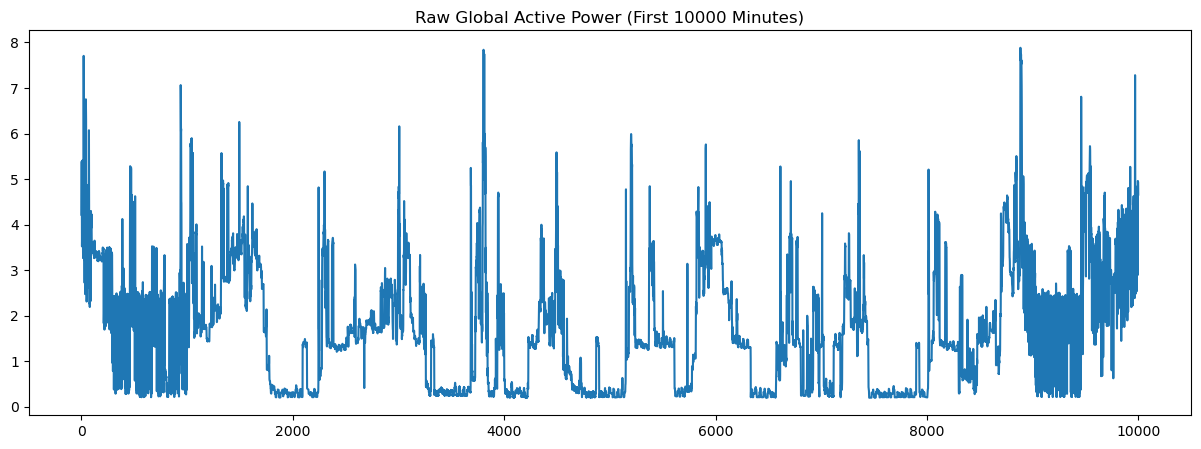

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['Global_active_power'][:10000])
plt.title("Raw Global Active Power (First 10000 Minutes)")
plt.show()


In [4]:
import pandas as pd

df['datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format='%d/%m/%Y %H:%M:%S'
)

# 把这个值作为索引，把普通表格作为真正的时间序列对象
df.set_index('datetime', inplace=True)

print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [5]:
# 转为数值（有些是字符串）
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'], errors='coerce')

print(df.shape)
df.head()

(2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
datetime,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


In [6]:
# 每分钟电能（kWh） 相当于新建了一个特征，计算公式是功率（kw）* 1/60小时 = 千瓦时
df['energy_per_minute'] = df['Global_active_power'] / 60

print(df.shape)
df.head()

(2075259, 10)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,energy_per_minute
datetime,,,,,,,,,,
2006-12-16 17:24:00,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,0.070267
2006-12-16 17:25:00,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,0.089333
2006-12-16 17:26:00,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,0.089567
2006-12-16 17:27:00,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,0.089800
2006-12-16 17:28:00,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,0.061100


In [7]:
# 按天求和 这里只有把上面的日期特征，变成标签，才可以按天聚合
# 得到每天的用电量
daily_energy = df['energy_per_minute'].resample('D').sum()

print(daily_energy.shape)
daily_energy.head()

(1442,)


datetime
2006-12-16    20.152933
2006-12-17    56.507667
2006-12-18    36.730433
2006-12-19    27.769900
2006-12-20    37.095800
Freq: D, Name: energy_per_minute, dtype: float64

In [8]:
# 检查时间序列标签的一些特征
print(type(df.index))
print(df.index[:5])
print(df.index.is_monotonic_increasing)


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00', '2006-12-16 17:27:00',
               '2006-12-16 17:28:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)
True


In [9]:
# 分析要进行预测的数据
print("最小值:", daily_energy.min())
print("最大值:", daily_energy.max())
print("均值:", daily_energy.mean())
print("标准差:", daily_energy.std())

最小值: 0.0
最大值: 79.55643333333333
均值: 25.85558092926491
标准差: 10.288285290632384


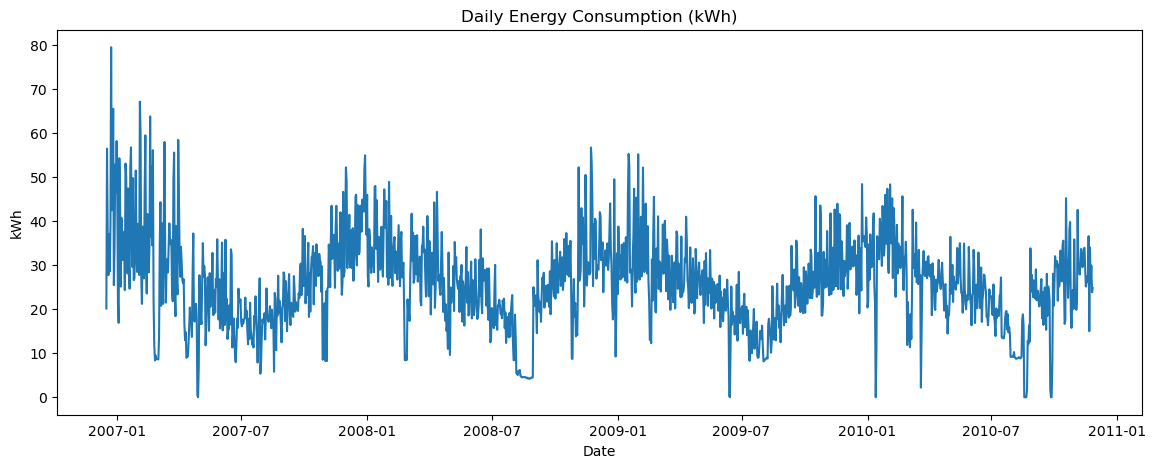

In [10]:
# 画图查看
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(daily_energy)
plt.title("Daily Energy Consumption (kWh)")
plt.xlabel("Date")
plt.ylabel("kWh")
plt.show()

In [11]:
daily_df = daily_energy.to_frame()

# 把他变成了一个表，分析别的特征，同样有时间index，然后1442天和1列，就是每天的用电量
print(daily_df.shape)
daily_df.head()


(1442, 1)


,energy_per_minute
datetime,
2006-12-16,20.152933
2006-12-17,56.507667
2006-12-18,36.730433
2006-12-19,27.769900
2006-12-20,37.095800


In [12]:
daily_df['weekday'] = daily_df.index.weekday

# 为了查看有没有周周期特征，用电量可能周末会高一点，工作日低一点
# 所以多加入一列特征，根据index计算他是星期几
# 0-6表示从星期一到星期天
print(daily_df.shape)
daily_df.head()

(1442, 2)


,energy_per_minute,weekday
datetime,,
2006-12-16,20.152933,5
2006-12-17,56.507667,6
2006-12-18,36.730433,0
2006-12-19,27.769900,1
2006-12-20,37.095800,2


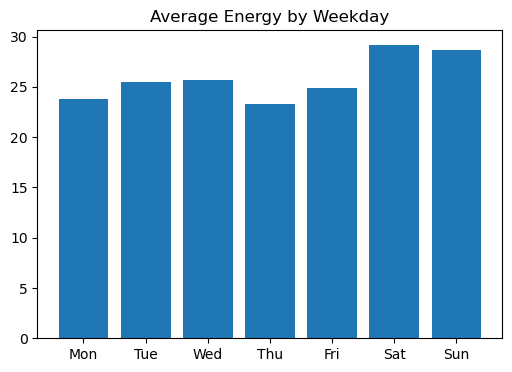

In [13]:
# 计算出这么多天里面，每个不同的天的平均用电量
weekly_mean = daily_df.groupby('weekday')['energy_per_minute'].mean()

plt.figure(figsize=(6,4))
plt.bar(weekly_mean.index, weekly_mean.values)
plt.xticks(range(7), ['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Average Energy by Weekday")
plt.show()

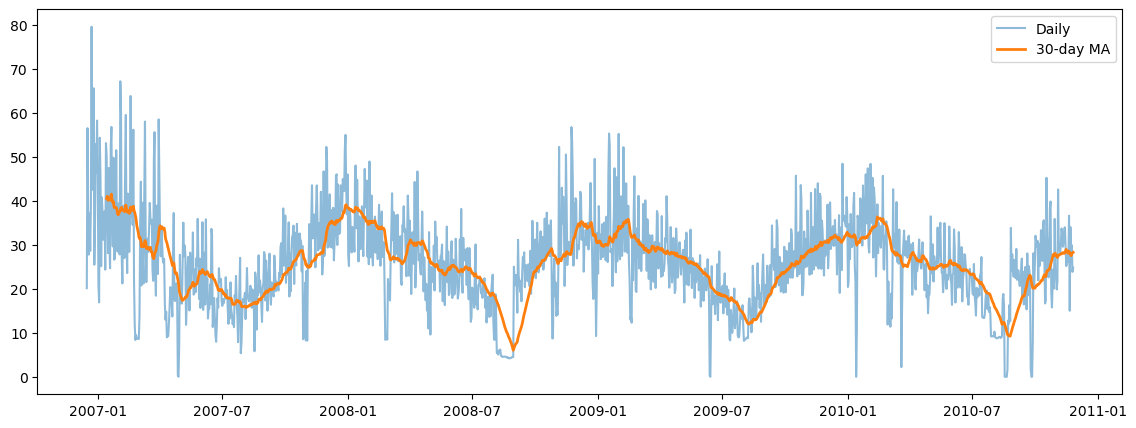

In [14]:
# 这一步是对每一天，求他的前三十天的均值，绘图，观察是否有趋势
# 图像显示每天的用电量呈现冬天高，夏天低
rolling_mean = daily_energy.rolling(30).mean()

plt.figure(figsize=(14,5))
plt.plot(daily_energy, alpha=0.5, label='Daily')
plt.plot(rolling_mean, linewidth=2, label='30-day MA')
plt.legend()
plt.show()

<Figure size 1000x500 with 0 Axes>

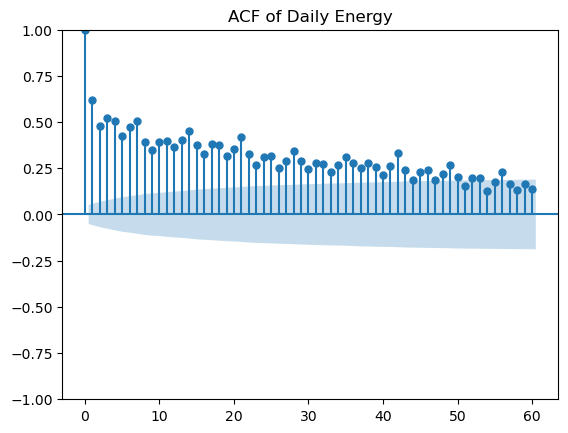

In [15]:
# 自相关函数ACF
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plot_acf(daily_energy, lags=60)
plt.title("ACF of Daily Energy")
plt.show()

<Figure size 1000x500 with 0 Axes>

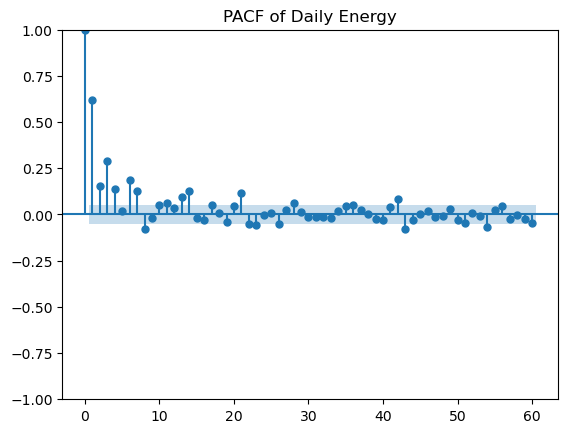

In [16]:
# 偏自相关PACF
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(10,5))
plot_pacf(daily_energy, lags=60)
plt.title("PACF of Daily Energy")
plt.show()


In [17]:
# 单位跟检验
from statsmodels.tsa.stattools import adfuller

result = adfuller(daily_energy)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -3.849776942163352
p-value: 0.002437177429858372


In [18]:
# 上面做的这些，都叫做时间序列结构诊断
# 通过诊断，可以决定ARIMA(p,d,q)的参数；ARIMA可以拆成AR, I, MA三个部分理解

In [19]:
# 静态多步预测
# 用前 75% 的数据训练 ARIMA
# 得到模型参数（φ）
# 从训练集最后一个点开始
# 一次性预测整个测试集长度
# 后面的预测全部基于“前面预测值”
# 导致收敛到均值
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import numpy as np

# 划分训练测试
train_size = int(len(daily_energy) * 0.75)
train = daily_energy[:train_size]
test = daily_energy[train_size:]

# RMSE是平均预测误差大小，AIC在模型复杂度和拟合效果之间做平衡，AIC越小越好
def evaluate_arima(order):
    model = ARIMA(train, order=order)
    model_fit = model.fit()

    forecast = model_fit.forecast(steps=len(test))
    rmse = np.sqrt(mean_squared_error(test, forecast))

    print(f"ARIMA{order} RMSE:", rmse)
    print("AIC:", model_fit.aic)
    return forecast

# 运行模型
forecast_2 = evaluate_arima((2,0,0))
forecast_3 = evaluate_arima((3,0,0))
forecast_7 = evaluate_arima((7,0,0))
forecast_201 = evaluate_arima((2,0,1))


ARIMA(2, 0, 0) RMSE: 9.173892077093264
AIC: 7662.233231928203
ARIMA(3, 0, 0) RMSE: 9.160365493190602
AIC: 7541.36011024666
ARIMA(7, 0, 0) RMSE: 9.110738765665102
AIC: 7454.503562811999


c:\Users\31062\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\31062\anaconda3\envs\ML\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2, 0, 1) RMSE: 9.126656844649638
AIC: 7523.867288262656


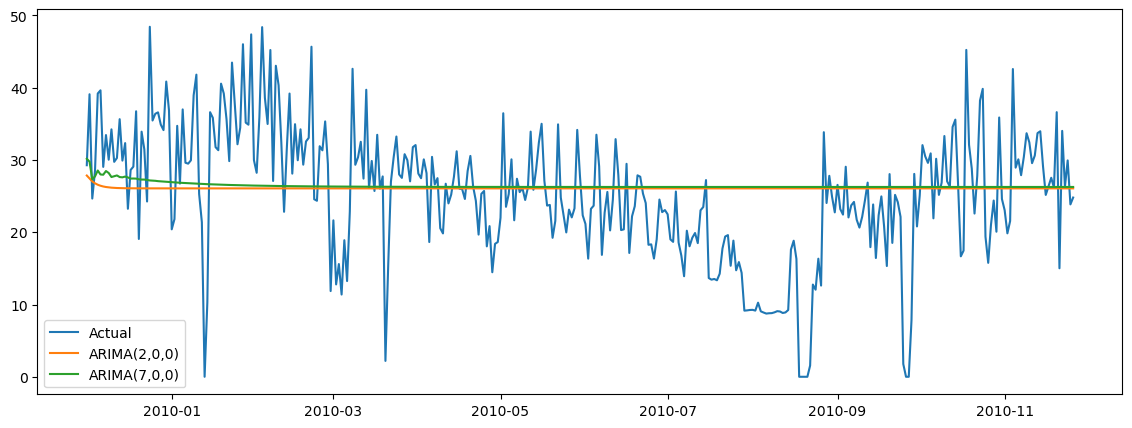

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, forecast_2, label="ARIMA(2,0,0)")
plt.plot(test.index, forecast_7, label="ARIMA(7,0,0)")
plt.legend()
plt.show()


In [21]:
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 保证是 numpy array
data = daily_energy.values

# 按整周划分（最后一年约52周）
n_weeks_test = 52
n_days_test = n_weeks_test * 7

train = data[:-n_days_test]
test = data[-n_days_test:]

print("Train days:", len(train))
print("Test days:", len(test))


Train days: 1078
Test days: 364


In [22]:
history = list(train)
predictions = []

for i in range(0, len(test), 7):
    
    # 用当前历史拟合 ARIMA(7,0,0)
    model = ARIMA(history, order=(7,0,0))
    model_fit = model.fit()
    
    # 预测未来7天
    yhat = model_fit.forecast(steps=7)
    
    # 保存预测
    predictions.append(yhat)
    
    # 加入真实值（滚动更新）
    history.extend(test[i:i+7])

predictions = np.array(predictions)


In [23]:
# 把 test 变成 (周数, 7天)
actual = test.reshape(-1, 7)

rmse_per_day = []

for day in range(7):
    rmse = np.sqrt(mean_squared_error(actual[:, day], predictions[:, day]))
    rmse_per_day.append(rmse)

print("每一天的 RMSE：")
for i, val in enumerate(rmse_per_day):
    print(f"Day {i+1}: {val:.3f}")


每一天的 RMSE：
Day 1: 8.142
Day 2: 8.487
Day 3: 7.107
Day 4: 6.121
Day 5: 8.195
Day 6: 7.687
Day 7: 6.100


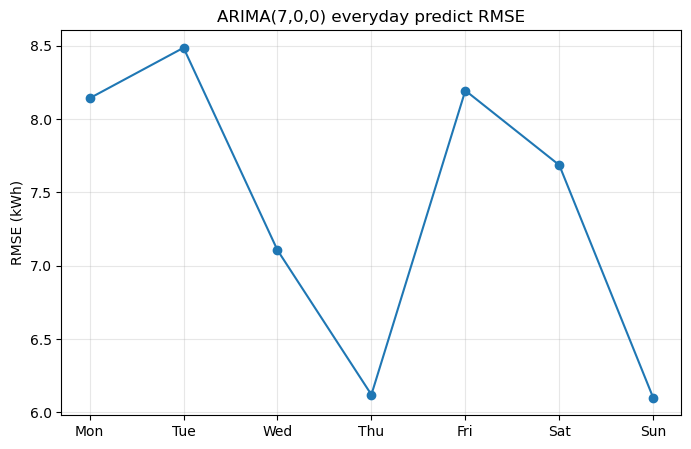

In [24]:
# 多步预测，每一天的误差都有可能不一样，所以需要统计窗口的每一个点的误差
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,5))
plt.plot(days, rmse_per_day, marker='o')
plt.title("ARIMA(7,0,0) everyday predict RMSE")
plt.ylabel("RMSE (kWh)")
plt.grid(alpha=0.3)
plt.show()


In [25]:
# 最简单的预测，今天和上周同一天一样，作为基线
import numpy as np
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

data = daily_energy.values

n_weeks_test = 52
n_days_test = n_weeks_test * 7

train = data[:-n_days_test]
test = data[-n_days_test:]

print("Train days:", len(train))
print("Test days:", len(test))

Train days: 1078
Test days: 364


In [26]:
history = list(train)
predictions = []

for i in range(0, len(test), 7):
    
    # 用上周同一天作为预测
    yhat = history[-7:]   # 直接复制最近7天
    
    predictions.append(yhat)
    
    # 更新历史（加入真实值）
    history.extend(test[i:i+7])

predictions = np.array(predictions)

In [27]:
actual = test.reshape(-1, 7)

rmse_per_day_naive = []

for day in range(7):
    rmse = np.sqrt(mean_squared_error(actual[:, day], predictions[:, day]))
    rmse_per_day_naive.append(rmse)

print("Seasonal Naive 每天的 RMSE：")
for i, val in enumerate(rmse_per_day_naive):
    print(f"Day {i+1}: {val:.3f}")


Seasonal Naive 每天的 RMSE：
Day 1: 11.826
Day 2: 12.109
Day 3: 9.651
Day 4: 7.862
Day 5: 10.564
Day 6: 9.337
Day 7: 7.408


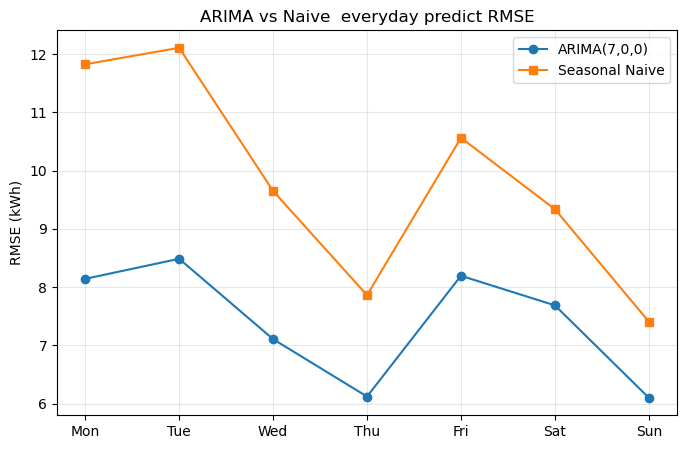

In [28]:
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

plt.figure(figsize=(8,5))
plt.plot(days, rmse_per_day, marker='o', label="ARIMA(7,0,0)")
plt.plot(days, rmse_per_day_naive, marker='s', label="Seasonal Naive")
plt.title("ARIMA vs Naive  everyday predict RMSE")
plt.ylabel("RMSE (kWh)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
